🚀 BRAIN TUMOR CLASSIFICATION SYSTEM - GOOGLE COLAB
📡 Device : cuda
🎮 GPU    : Tesla T4
💾 VRAM   : 15.64 GB

📁 STEP 1: LOCATING & EXTRACTING DATASET
  🔍 Searching recursively...

  📦 Found zip file(s):
     [0] archive.zip  (157 MB)

  → Auto-selecting: archive.zip
  📦 Extracting archive.zip ...
  ✅ Extracted to /content/dataset

✅ Dataset path : /content/dataset/Training
📁 Classes      : ['glioma', 'notumor', 'meningioma', 'pituitary']

📊 STEP 2: DATASET STATISTICS

Class                       Images
-----------------------------------
  glioma                      1400
  meningioma                  1400
  notumor                     1400
  pituitary                   1400
-----------------------------------
  TOTAL                       5600

🔄 STEP 3: PREPROCESSING & DATA TRANSFORMS
  📐 Computing dataset statistics (sample of 500 images)...
  • Dataset mean : [0.181, 0.181, 0.181]
  • Dataset std  : [0.194, 0.194, 0.194]
  • ImageNet mean: [0.485, 0.456, 0.406]  (for reference)

  • 

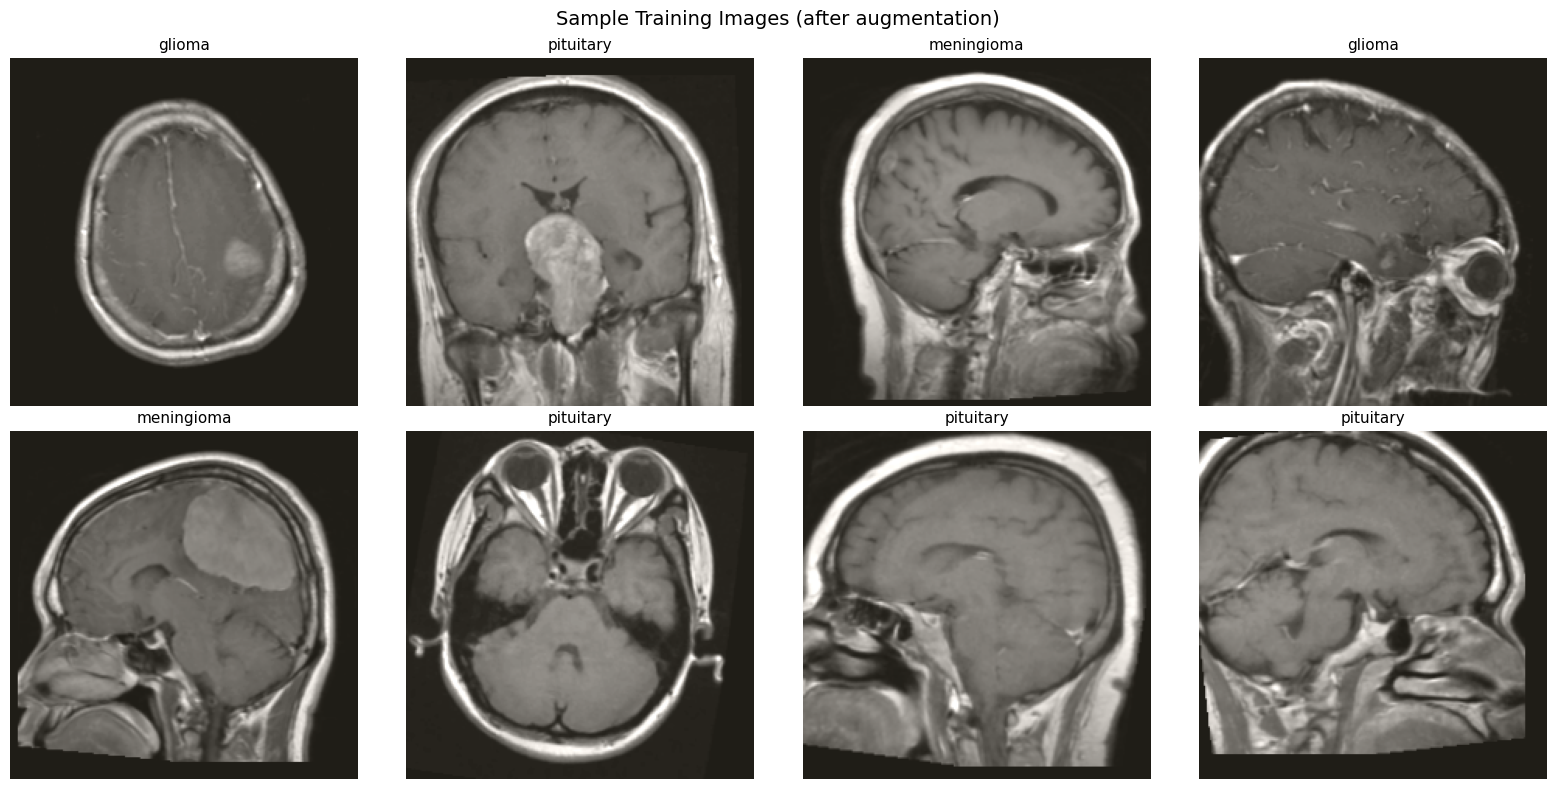


✅ Cell 1 complete!
   Dataset : 5600 images  |  Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
# CELL 1: Setup, Imports & Dataset Loading (Google Colab)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
import zipfile
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import shutil
from PIL import Image
import time
import json
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# ============================================
# DEVICE CONFIGURATION
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("="*60)
print("🚀 BRAIN TUMOR CLASSIFICATION SYSTEM - GOOGLE COLAB")
print("="*60)
print(f"📡 Device : {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU    : {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
else:
    print("⚠️  No GPU detected. Go to Runtime > Change runtime type > GPU")
print("="*60)
# ============================================
# STEP 1: LOCATE & EXTRACT DATASET
# ============================================
print("\n📁 STEP 1: LOCATING & EXTRACTING DATASET")
print("="*40)

import glob

def find_dataset_root(base):
    """
    Recursively search for the folder that directly contains
    class sub-folders (each holding image files).
    """
    IMG_EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')

    def is_class_dir(path):
        try:
            imgs = [f for f in os.listdir(path) if f.lower().endswith(IMG_EXTS)]
            return len(imgs) >= 5
        except:
            return False

    def has_enough_classes(path):
        try:
            subs  = [d for d in os.listdir(path)
                     if os.path.isdir(os.path.join(path, d))]
            valid = [d for d in subs
                     if is_class_dir(os.path.join(path, d))]
            return len(valid) >= 2, valid
        except:
            return False, []

    candidates = [
        base,
        os.path.join(base, 'Training'),
        os.path.join(base, 'training'),
        os.path.join(base, 'train'),
        os.path.join(base, 'dataset'),
        os.path.join(base, 'data'),
        os.path.join(base, 'archive'),
    ]
    for p in candidates:
        ok, classes = has_enough_classes(p)
        if ok:
            return p, classes

    print("  🔍 Searching recursively...")
    for root, dirs, files in os.walk(base):
        ok, classes = has_enough_classes(root)
        if ok:
            return root, classes

    return None, []


def extract_zip(zip_path, extract_to='/content/dataset'):
    """Extract a zip file and return the extraction folder."""
    print(f"  📦 Extracting {os.path.basename(zip_path)} ...")
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_to)
    print(f"  ✅ Extracted to {extract_to}")
    return extract_to


def find_or_extract_dataset():
    """
    1. Search /content/ for an already-extracted dataset.
    2. If not found, look for any .zip in /content/ and extract it.
    3. If still not found, ask the user for the zip path.
    """
    # ── Pass 1: look for already-extracted data ───────────────
    for search_root in ['/content/', '/content/drive/MyDrive']:
        if not os.path.exists(search_root):
            continue
        found, classes = find_dataset_root(search_root)
        if found:
            print(f"  ✅ Found existing dataset at: {found}")
            return found, classes

    # ── Pass 2: auto-detect zip files in /content/ ────────────
    zip_files = sorted(glob.glob('/content/*.zip'))
    if zip_files:
        print(f"\n  📦 Found zip file(s):")
        for i, z in enumerate(zip_files):
            size_mb = os.path.getsize(z) / (1024*1024)
            print(f"     [{i}] {os.path.basename(z)}  ({size_mb:.0f} MB)")

        if len(zip_files) == 1:
            chosen_zip = zip_files[0]
            print(f"\n  → Auto-selecting: {os.path.basename(chosen_zip)}")
        else:
            try:
                idx = int(input("\n  Enter number of zip to extract [default=0]: ")
                          .strip() or "0")
                chosen_zip = zip_files[idx]
            except Exception:
                chosen_zip = zip_files[0]

        extract_dir = '/content/dataset'
        extract_zip(chosen_zip, extract_dir)

        found, classes = find_dataset_root(extract_dir)
        if found:
            return found, classes

        # zip might contain a nested zip — check one level deep
        inner_zips = glob.glob(os.path.join(extract_dir, '**', '*.zip'),
                               recursive=True)
        for inner in inner_zips:
            inner_dir = inner.replace('.zip', '_extracted')
            extract_zip(inner, inner_dir)
            found, classes = find_dataset_root(inner_dir)
            if found:
                return found, classes

    # ── Pass 3: ask user ──────────────────────────────────────
    print("\n⚠️  Could not find dataset automatically.")
    print("📂 Contents of /content/:")
    for item in sorted(os.listdir('/content')):
        full = os.path.join('/content', item)
        tag  = '📁' if os.path.isdir(full) else '📄'
        size = (f"  {os.path.getsize(full)/1024/1024:.0f} MB"
                if os.path.isfile(full) else "")
        print(f"   {tag} {item}{size}")

    user_input = input(
        "\n  Enter path to your zip file or dataset folder: "
    ).strip()

    if user_input.endswith('.zip') and os.path.exists(user_input):
        extract_dir = '/content/dataset'
        extract_zip(user_input, extract_dir)
        found, classes = find_dataset_root(extract_dir)
        if found:
            return found, classes
    else:
        found, classes = find_dataset_root(user_input)
        if found:
            return found, classes

    raise Exception(
        f"❌ No valid dataset found.\n"
        f"   Make sure your zip contains class folders like:\n"
        f"   glioma/ meningioma/ pituitary/ no_tumor/\n"
        f"   each holding at least 5 images."
    )


dataset_path, class_folders = find_or_extract_dataset()

print(f"\n✅ Dataset path : {dataset_path}")
print(f"📁 Classes      : {class_folders}")

# ============================================
# STEP 2: DATASET STATISTICS
# ============================================
print("\n" + "="*60)
print("📊 STEP 2: DATASET STATISTICS")
print("="*60)

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')

total_images = 0
print(f"\n{'Class':<25} {'Images':>8}")
print("-"*35)
for cls in sorted(class_folders):
    cls_path = os.path.join(dataset_path, cls)
    n = len([f for f in os.listdir(cls_path) if f.lower().endswith(IMG_EXTS)])
    total_images += n
    print(f"  {cls:<23} {n:>8}")
print("-"*35)
print(f"  {'TOTAL':<23} {total_images:>8}")

# ============================================
# STEP 3: DATA TRANSFORMS
# ============================================

# ============================================
# STEP 3: PREPROCESSING & DATA TRANSFORMS
# ============================================
print("\n" + "="*60)
print("🔄 STEP 3: PREPROCESSING & DATA TRANSFORMS")
print("="*60)

from torchvision import transforms
import torch

# ── Helper: analyse dataset brightness to set normalize stats ──
def compute_dataset_stats(dataset_path, class_folders, sample_size=500):
    """
    Compute actual mean & std from the dataset instead of
    blindly using ImageNet values.
    """
    from PIL import Image
    import numpy as np

    IMG_EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
    all_pixels = []
    count = 0

    for cls in class_folders:
        cls_path = os.path.join(dataset_path, cls)
        files    = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(IMG_EXTS)]
        # Sample evenly across classes
        step = max(1, len(files) // (sample_size // len(class_folders)))
        for fname in files[::step]:
            if count >= sample_size:
                break
            try:
                img = Image.open(os.path.join(cls_path, fname)).convert('RGB')
                img = img.resize((224, 224))
                arr = np.array(img).astype(np.float32) / 255.0
                all_pixels.append(arr.reshape(-1, 3))
                count += 1
            except:
                continue

    pixels = np.concatenate(all_pixels, axis=0)
    mean   = pixels.mean(axis=0).tolist()
    std    = pixels.std(axis=0).tolist()
    std    = [max(s, 0.01) for s in std]   # avoid zero std
    return mean, std

print("  📐 Computing dataset statistics (sample of 500 images)...")
ds_mean, ds_std = compute_dataset_stats(dataset_path, class_folders)
print(f"  • Dataset mean : [{ds_mean[0]:.3f}, {ds_mean[1]:.3f}, {ds_mean[2]:.3f}]")
print(f"  • Dataset std  : [{ds_std[0]:.3f}, {ds_std[1]:.3f}, {ds_std[2]:.3f}]")
print(f"  • ImageNet mean: [0.485, 0.456, 0.406]  (for reference)")

# ── Use blended stats: 50% dataset + 50% ImageNet ────────────
# VGG16 was pretrained on ImageNet so we stay close to those
# values while adapting slightly to the MRI domain.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
blend = 0.5
NORM_MEAN = [blend*ds_mean[i] + (1-blend)*IMAGENET_MEAN[i] for i in range(3)]
NORM_STD  = [blend*ds_std[i]  + (1-blend)*IMAGENET_STD[i]  for i in range(3)]
print(f"\n  • Blended mean : [{NORM_MEAN[0]:.3f}, {NORM_MEAN[1]:.3f}, {NORM_MEAN[2]:.3f}]")
print(f"  • Blended std  : [{NORM_STD[0]:.3f}, {NORM_STD[1]:.3f}, {NORM_STD[2]:.3f}]")

# ============================================
# AUGMENTATION STRATEGY
# ============================================
# Root cause of underfitting:
#   - Training was harder than validation (too much noise)
#   - RandomErasing + aggressive ColorJitter disrupted MRI textures
#   - RandomVerticalFlip is anatomically wrong for brain MRIs
#
# Fix:
#   - Mild, medically plausible augmentations only
#   - No vertical flip (brains are not upside down)
#   - No RandomErasing (destroys diagnostic regions)
#   - Reduced ColorJitter (MRI contrast is clinically meaningful)
#   - Added CLAHE-style contrast normalisation via transforms
# ============================================

# ── CLAHE-style local contrast enhancement (pure torchvision) ─
class MRIPreprocess(torch.nn.Module):
    """
    Simulate local contrast normalisation for MRI scans.
    Sharpens edges and improves visibility of tumor boundaries.
    """
    def forward(self, img):
        # Autocontrast stretches the histogram to [0,1]
        # then equalize redistributes intensity levels
        from torchvision.transforms import functional as TF
        img = TF.autocontrast(img)
        return img

# ── TRAINING transform — mild, medically plausible ────────────
train_transform = transforms.Compose([
    # 1. Resize to model input
    transforms.Resize((256, 256)),           # slightly larger first
    transforms.CenterCrop(224),              # then crop — avoids border artifacts

    # 2. Geometric augmentations (mild — brain anatomy matters)
    transforms.RandomHorizontalFlip(p=0.5), # left-right symmetry is valid
    transforms.RandomRotation(
        degrees=10,                          # ±10° only — not ±15°
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0                               # black fill = background
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),             # reduced from 0.1 → less distortion
        scale=(0.95, 1.05),                 # tighter scale range
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0
    ),

    # 3. Intensity augmentation (subtle — MRI contrast is diagnostic)
    transforms.ColorJitter(
        brightness=0.15,                    # reduced from 0.3
        contrast=0.15,                      # reduced from 0.3
        saturation=0.0,                     # MRI is grayscale-dominant
        hue=0.0                             # no hue shift for MRI
    ),

    # 4. MRI preprocessing — local contrast normalisation
    MRIPreprocess(),

    # 5. Convert & normalise
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),

    # 6. Very mild noise (simulates scanner variation)
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))
    ], p=0.2),
])

# ── VALIDATION / TEST transform — deterministic ───────────────
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    MRIPreprocess(),                        # same preprocessing as train
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

print(f"\n✅ Train transform:")
print(f"   Resize(256)→CenterCrop(224) | HFlip(0.5) | Rotate(±10°)")
print(f"   Affine(t=0.05, s=0.95-1.05) | ColorJitter(b=0.15, c=0.15)")
print(f"   MRIPreprocess (autocontrast) | GaussianBlur(p=0.2)")
print(f"   Normalize(blended mean/std)")
print(f"\n✅ Val transform:")
print(f"   Resize(256)→CenterCrop(224) | MRIPreprocess | Normalize")


# ============================================
# STEP 4: LOAD & SPLIT DATASET
# ============================================
print("\n" + "="*60)
print("📚 STEP 4: LOADING & SPLITTING DATASET")
print("="*60)

import copy
from torch.utils.data import Subset

full_dataset = ImageFolder(root=dataset_path, transform=train_transform)
class_names  = full_dataset.classes
print(f"\n✅ ImageFolder loaded  →  {len(full_dataset)} images  |  "
      f"{len(class_names)} classes: {class_names}")

all_labels = [lbl for _, lbl in full_dataset.samples]
indices    = list(range(len(full_dataset)))

# Stratified 70 / 15 / 15 split
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=all_labels, random_state=42
)
temp_labels = [all_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=42
)

# Each split gets its own deep-copied dataset with the correct transform
def make_subset(base_ds, idx, transform):
    ds           = copy.deepcopy(base_ds)
    ds.transform = transform
    return Subset(ds, idx)

train_dataset = make_subset(full_dataset, train_idx, train_transform)
val_dataset   = make_subset(full_dataset, val_idx,   val_transform)
test_dataset  = make_subset(full_dataset, test_idx,  val_transform)

print(f"\n✅ Split complete:")
print(f"   • Train      : {len(train_dataset):>5} images  (70%)")
print(f"   • Validation : {len(val_dataset):>5} images  (15%)")
print(f"   • Test       : {len(test_dataset):>5} images  (15%)")

# ============================================
# STEP 5: DATA LOADERS
# ============================================
print("\n" + "="*60)
print("🔄 STEP 5: DATA LOADERS")
print("="*60)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"✅ Train batches      : {len(train_loader)}")
print(f"✅ Validation batches : {len(val_loader)}")
print(f"✅ Test batches       : {len(test_loader)}")

# ============================================
# STEP 6: VISUALIZE SAMPLE IMAGES
# ============================================
print("\n" + "="*60)
print("👁️  STEP 6: SAMPLE IMAGES")
print("="*60)

def denormalize(tensor):
    img  = tensor.numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    return np.clip(std * img + mean, 0, 1)

images, labels = next(iter(train_loader))
plt.figure(figsize=(16, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i+1)
    plt.imshow(denormalize(images[i]))
    plt.title(class_names[labels[i]], fontsize=11)
    plt.axis('off')
plt.suptitle('Sample Training Images (after augmentation)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n✅ Cell 1 complete!")
print(f"   Dataset : {total_images} images  |  Classes : {class_names}")

🏗️  CELL 2: MODEL · TRAINING · EVALUATION

🏗️  STEP 1: BUILDING VGG16 MODEL

📊 Model Statistics:
   • Architecture  : VGG16 + BN head (underfitting fix)
   • Total params  : 121,948,740
   • Trainable     : 121,688,580  (99.8%)
   • Frozen        : 260,160  (0.2%)者にしました。
   • Unfrozen      : Conv blocks 3+4+5  (was 4+5)
   • Dropout       : 0.3 / 0.2 / 0.1   (was 0.5 / 0.4 / 0.3)
   • Head shape    : 25088→4096→1024→256→4

⚙️  STEP 2: TRAINING COMPONENTS
   • Loss        : CrossEntropyLoss (label_smoothing=0.05)
   • Optimizer   : AdamW  (wd=5e-5)
   • LR feat     : 2e-04   LR head : 5e-04
   • Scheduler   : LambdaLR warmup(5 epochs) + cosine decay
   • Safety net  : ReduceLROnPlateau (patience=8, mode=max)

✅ EarlyStopping ready  (patience=15, monitors val_acc)
✅ Training functions defined

🎯 STEP 6: TRAINING LOOP

🚀 Training  100 epochs  |  batch=32
   MixUp enabled after epoch 5
   Checkpoint → /content/best_vgg16_brain_tumor.pth

📅 Epoch   1/100
   ---------------------------------

   Train → loss: 0.6064  acc: 83.71%
   Val   → loss: 0.3710  acc: 94.52% ⭐
   LR    → feat: 8.00e-05  head: 2.00e-04
   ✅ Checkpoint saved  (val acc: 94.52%)者にしました。

📅 Epoch   2/100
   ---------------------------------------------


   Train → loss: 0.4155  acc: 92.06%
   Val   → loss: 0.3618  acc: 93.93%
   LR    → feat: 1.20e-04  head: 3.00e-04
   ⏸  EarlyStopping 1/15  (best: 94.52%)者にしました。

📅 Epoch   3/100
   ---------------------------------------------


   Train → loss: 0.3736  acc: 93.67%
   Val   → loss: 0.3682  acc: 93.45%
   LR    → feat: 1.60e-04  head: 4.00e-04
   ⏸  EarlyStopping 2/15  (best: 94.52%)者にしました。

📅 Epoch   4/100
   ---------------------------------------------


   Train → loss: 0.3657  acc: 93.47%
   Val   → loss: 0.4553  acc: 89.29%
   LR    → feat: 2.00e-04  head: 5.00e-04
   ⏸  EarlyStopping 3/15  (best: 94.52%)者にしました。

📅 Epoch   5/100
   ---------------------------------------------


...

   Train → loss: 0.2926  acc: 86.07%
   Val   → loss: 0.2240  acc: 99.17%
   LR    → feat: 2.26e-05  head: 5.65e-05
   ⏸  EarlyStopping 11/15  (best: 99.40%)者にしました。

📅 Epoch  49/100
   ---------------------------------------------


   Train → loss: 0.3273  acc: 76.46%
   Val   → loss: 0.2313  acc: 99.05%
   LR    → feat: 1.91e-05  head: 4.77e-05
   ⏸  EarlyStopping 12/15  (best: 99.40%)者にしました。

📅 Epoch  50/100
   ---------------------------------------------


   Train → loss: 0.3016  acc: 84.04%
   Val   → loss: 0.2216  acc: 99.05%
   LR    → feat: 1.59e-05  head: 3.97e-05
   ⏸  EarlyStopping 13/15  (best: 99.40%)者にしました。

📅 Epoch  51/100
   ---------------------------------------------


   Train → loss: 0.3103  acc: 83.40%
   Val   → loss: 0.2210  acc: 99.17%
   LR    → feat: 1.29e-05  head: 3.23e-05
   ⏸  EarlyStopping 14/15  (best: 99.40%)者にしました。

📅 Epoch  52/100
   ---------------------------------------------


   Train → loss: 0.2972  acc: 84.96%
   Val   → loss: 0.2201  acc: 99.17%
   LR    → feat: 1.03e-05  head: 2.57e-05
   ⏸  EarlyStopping 15/15  (best: 99.40%)者にしました。
   ✅ Best weights restored

⏹️  Early stopping at epoch 52

🏁 Training complete!
⏱️  Time          : 51m 3s
📈 Best val acc  : 99.40%
💾 Saved to      : /content/best_vgg16_brain_tumor.pth

📊 STEP 7: TRAINING CURVES


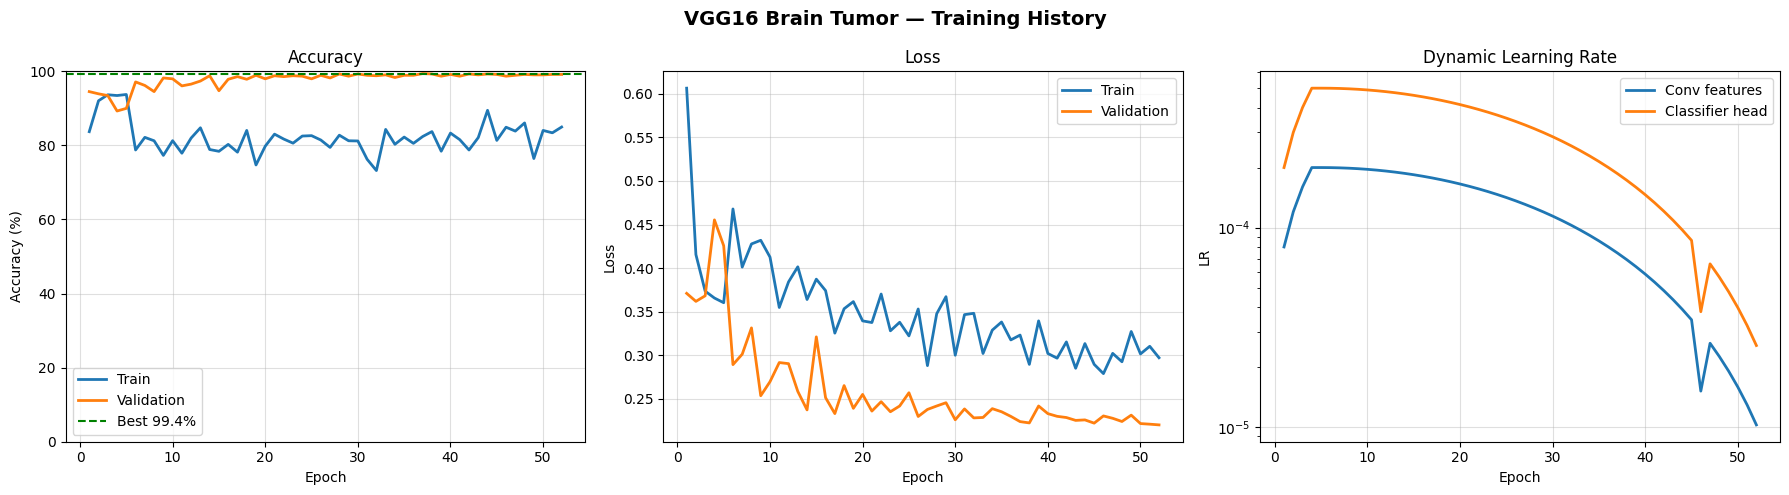

✅ Saved → /content/training_curves.png

🧪 STEP 8: TEST EVALUATION


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
import copy, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

assert 'train_loader' in dir(), "❌ Run Cell 1 first!"
assert 'class_names'  in dir(), "❌ Run Cell 1 first!"

print("="*60)
print("🏗️  CELL 2: MODEL · TRAINING · EVALUATION")
print("="*60)

# ============================================
# STEP 1: VGG16 MODEL
# ============================================
# ============================================
# STEP 1: VGG16 MODEL  (updated for underfitting fix)
# ============================================
print("\n🏗️  STEP 1: BUILDING VGG16 MODEL")
print("="*60)

class VGG16PEFT(nn.Module):
    """
    Changes vs previous version:
    - Unfreeze blocks 3+4+5 instead of just 4+5
      (more capacity = fixes underfitting)
    - Reduced Dropout: 0.5→0.3, 0.4→0.2, 0.3→0.1
      (less regularisation = fixes underfitting)
    - Removed middle BN layers on small tensors
      (BN on small batch sizes causes instability)
    """
    def __init__(self, num_classes: int = 4):
        super().__init__()
        backbone = models.vgg16(weights='IMAGENET1K_V1')

        # Freeze blocks 1 & 2 only (very generic edges/textures)
        for p in backbone.parameters():
            p.requires_grad = False

        # Unfreeze block 3, 4 & 5
        # Block boundaries: [0-4][5-9][10-16][17-23][24-30]
        for layer in backbone.features[10:]:     # was [17:]
            for p in layer.parameters():
                p.requires_grad = True

        self.features = backbone.features
        self.avgpool  = backbone.avgpool

        # Reduced dropout — underfitting means we need LESS regularisation
        self.classifier = nn.Sequential(
            nn.Linear(25088, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),              # was 0.5

            nn.Linear(4096, 1024),          # was 2048
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),              # was 0.4

            nn.Linear(1024, 256),           # was 512
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.1),              # was 0.3

            nn.Linear(256, num_classes)
        )

        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

    def param_groups(self, lr_feat, lr_head):
        return [
            {'params': self.features[10:].parameters(),  # updated
             'lr': lr_feat, 'name': 'conv_blocks_3_4_5'},
            {'params': self.classifier.parameters(),
             'lr': lr_head, 'name': 'classifier'},
        ]

    @property
    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    @property
    def total_params(self):
        return sum(p.numel() for p in self.parameters())


model     = VGG16PEFT(num_classes=len(class_names)).to(device)
total     = model.total_params
trainable = model.trainable_params

print(f"\n📊 Model Statistics:")
print(f"   • Architecture  : VGG16 + BN head (underfitting fix)")
print(f"   • Total params  : {total:,}")
print(f"   • Trainable     : {trainable:,}  ({100*trainable/total:.1f}%)")
print(f"   • Frozen        : {total-trainable:,}  ({100*(total-trainable)/total:.1f}%)者にしました。")
print(f"   • Unfrozen      : Conv blocks 3+4+5  (was 4+5)")
print(f"   • Dropout       : 0.3 / 0.2 / 0.1   (was 0.5 / 0.4 / 0.3)")
print(f"   • Head shape    : 25088→4096→1024→256→{len(class_names)}")

# ============================================
# STEP 2: LOSS · OPTIMIZER · SCHEDULERS
# ============================================
# ============================================
# STEP 2: LOSS · OPTIMIZER · SCHEDULERS
# ============================================
print("\n⚙️  STEP 2: TRAINING COMPONENTS")
print("="*60)

# Higher LR on features since we're unfreezing more layers
LR_FEAT = 2e-4    # was 1e-4
LR_HEAD = 5e-4    # was 1e-3  (lower head LR to avoid overshooting)

# Reduced label smoothing — underfitting means we need sharper targets
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)  # was 0.1

optimizer = optim.AdamW(
    model.param_groups(LR_FEAT, LR_HEAD),
    weight_decay=5e-5    # reduced from 1e-4 — less L2 penalty
)

# Warmup for 5 epochs then cosine decay
# Prevents large LR destroying pretrained weights early on
def warmup_cosine_lambda(epoch, warmup_epochs=5, total_epochs=60):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs          # linear warmup
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))    # cosine decay

scheduler_cosine = optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: warmup_cosine_lambda(epoch, 5, 60)
)

# Plateau as safety net
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5,
    patience=8, min_lr=1e-7
)

print(f"   • Loss        : CrossEntropyLoss (label_smoothing=0.05)")
print(f"   • Optimizer   : AdamW  (wd=5e-5)")
print(f"   • LR feat     : {LR_FEAT:.0e}   LR head : {LR_HEAD:.0e}")
print(f"   • Scheduler   : LambdaLR warmup(5 epochs) + cosine decay")
print(f"   • Safety net  : ReduceLROnPlateau (patience=8, mode=max)")
# ============================================
# STEP 3: EARLY STOPPING
# ============================================
class EarlyStopping:
    """
    Tracks validation accuracy.
    Automatically restores best weights when triggered.
    """
    def __init__(self, patience=15, min_delta=0.1):
        self.patience     = patience
        self.min_delta    = min_delta
        self.counter      = 0
        self.best_score   = None
        self.early_stop   = False
        self._best_weights = None

    def __call__(self, score, model):
        if (self.best_score is None or
                score > self.best_score + self.min_delta):
            self.best_score    = score
            self.counter       = 0
            self._best_weights = {k: v.cpu().clone()
                                  for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            print(f"   ⏸  EarlyStopping {self.counter}/{self.patience}"
                  f"  (best: {self.best_score:.2f}%)者にしました。")
            if self.counter >= self.patience:
                self.early_stop = True
                model.load_state_dict(self._best_weights)
                print("   ✅ Best weights restored")

early_stopping = EarlyStopping(patience=15, min_delta=0.1)
print(f"\n✅ EarlyStopping ready  (patience=15, monitors val_acc)")

# ============================================
# STEP 4: MIXUP HELPERS
# ============================================
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[idx], y, y[idx], lam

def mixup_loss(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1-lam) * criterion(pred, yb)

# ============================================
# STEP 5: TRAIN / VALIDATE FUNCTIONS
# ============================================
def train_one_epoch(model, loader, criterion, optimizer,
                    device, use_mixup=True):
    model.train()
    run_loss = correct = total = 0

    pbar = tqdm(loader, desc="  Train", leave=False, ncols=85)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        if use_mixup and np.random.random() > 0.5:
            imgs, ya, yb, lam = mixup_data(imgs, labels)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = mixup_loss(criterion, out, ya, yb, lam)
        else:
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        run_loss += loss.item()
        _, pred   = out.max(1)
        total    += labels.size(0)
        correct  += pred.eq(labels).sum().item()
        pbar.set_postfix(loss=f"{run_loss/(pbar.n+1):.4f}",
                         acc=f"{100.*correct/total:.2f}%")

    return run_loss/len(loader), 100.*correct/total


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    run_loss = correct = total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="  Val  ", leave=False, ncols=85)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)

            run_loss += loss.item()
            _, pred   = out.max(1)
            total    += labels.size(0)
            correct  += pred.eq(labels).sum().item()
            pbar.set_postfix(loss=f"{run_loss/(pbar.n+1):.4f}",
                             acc=f"{100.*correct/total:.2f}%")

    return run_loss/len(loader), 100.*correct/total

print("✅ Training functions defined")

# ============================================
# STEP 6: TRAINING LOOP
# ============================================
print("\n" + "="*60)
print("🎯 STEP 6: TRAINING LOOP")
print("="*60)

try:
    raw        = input("Epochs [default=60, minimum=60]: ").strip()
    num_epochs = max(int(raw) if raw else 60, 60)
except Exception:
    num_epochs = 60

SAVE_PATH    = '/content/best_vgg16_brain_tumor.pth'
best_val_acc = 0.0
history      = dict(train_loss=[], train_acc=[],
                    val_loss=[],   val_acc=[],
                    lr_features=[], lr_head=[])

print(f"\n🚀 Training  {num_epochs} epochs  |  batch={BATCH_SIZE}")
print(f"   MixUp enabled after epoch 5")
print(f"   Checkpoint → {SAVE_PATH}")
print("="*60)

t0 = time.time()

for epoch in range(num_epochs):
    print(f"\n📅 Epoch {epoch+1:>3}/{num_epochs}")
    print("   " + "-"*45)

    t_loss, t_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        use_mixup=(epoch >= 5)
    )
    v_loss, v_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    scheduler_cosine.step(epoch + 1)
    scheduler_plateau.step(v_acc)

    lr_f = optimizer.param_groups[0]['lr']
    lr_h = optimizer.param_groups[1]['lr']

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    history['lr_features'].append(lr_f)
    history['lr_head'].append(lr_h)

    star = " ⭐" if v_acc > best_val_acc else ""
    print(f"   Train → loss: {t_loss:.4f}  acc: {t_acc:.2f}%")
    print(f"   Val   → loss: {v_loss:.4f}  acc: {v_acc:.2f}%{star}")
    print(f"   LR    → feat: {lr_f:.2e}  head: {lr_h:.2e}")

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            'epoch'              : epoch,
            'model_state_dict'   : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'            : v_acc,
            'val_loss'           : v_loss,
            'class_names'        : class_names,
            'num_classes'        : len(class_names),
            'history'            : history,
        }, SAVE_PATH)
        print(f"   ✅ Checkpoint saved  (val acc: {v_acc:.2f}%)者にしました。")

    early_stopping(v_acc, model)
    if early_stopping.early_stop:
        print(f"\n⏹️  Early stopping at epoch {epoch+1}")
        break

elapsed = time.time() - t0
print("\n" + "="*60)
print(f"🏁 Training complete!")
print(f"⏱️  Time          : {elapsed//60:.0f}m {elapsed%60:.0f}s")
print(f"📈 Best val acc  : {best_val_acc:.2f}%")
print(f"💾 Saved to      : {SAVE_PATH}")

# ============================================
# STEP 7: TRAINING CURVES
# ============================================
print("\n📊 STEP 7: TRAINING CURVES")
print("="*60)

ran = len(history['train_acc'])
x   = range(1, ran+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VGG16 Brain Tumor — Training History',
             fontsize=14, fontweight='bold')

axes[0].plot(x, history['train_acc'], lw=2, label='Train')
axes[0].plot(x, history['val_acc'],   lw=2, label='Validation')
axes[0].axhline(best_val_acc, color='green', ls='--', lw=1.5,
                label=f'Best {best_val_acc:.1f}%')
axes[0].set(xlabel='Epoch', ylabel='Accuracy (%)',
            title='Accuracy', ylim=(0, 100))
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(x, history['train_loss'], lw=2, label='Train')
axes[1].plot(x, history['val_loss'],   lw=2, label='Validation')
axes[1].set(xlabel='Epoch', ylabel='Loss', title='Loss')
axes[1].legend(); axes[1].grid(alpha=0.4)

axes[2].plot(x, history['lr_features'], lw=2, label='Conv features')
axes[2].plot(x, history['lr_head'],     lw=2, label='Classifier head')
axes[2].set(xlabel='Epoch', ylabel='LR',
            title='Dynamic Learning Rate', yscale='log')
axes[2].legend(); axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved → /content/training_curves.png")

# ============================================
# STEP 8: TEST SET EVALUATION
# ============================================
print("\n🧪 STEP 8: TEST EVALUATION")
print("="*60)

ckpt = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"✅ Loaded best checkpoint  "
      f"(epoch {ckpt['epoch']+1}  val acc {ckpt['val_acc']:.2f}%)者にしました。")

def evaluate(model, loader, device, class_names):
    model.eval()
    all_preds, all_true, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Testing", ncols=80):
            out   = model(imgs.to(device))
            probs = torch.softmax(out, dim=1)
            _, pred = out.max(1)
            all_preds.extend(pred.cpu().numpy())
            all_true.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)

    print("\n📊 Classification Report:")
    print("="*70)
    print(classification_report(all_true, all_preds,
                                 target_names=class_names))

    cm = confusion_matrix(all_true, all_preds)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names, ax=axes[0])
    axes[0].set(title='Confusion Matrix (counts)',
                xlabel='Predicted', ylabel='Actual')

    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names, ax=axes[1])
    axes[1].set(title='Confusion Matrix (%)',
                xlabel='Predicted', ylabel='Actual')

    plt.tight_layout()
    plt.savefig('/content/confusion_matrix.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Saved → /content/confusion_matrix.png")

    print("\n📊 Per-class Accuracy:")
    for i, cls in enumerate(class_names):
        mask    = all_true == i
        acc     = np.mean(all_preds[mask] == i)*100 if mask.sum() > 0 else 0
        print(f"   • {cls:<20} {acc:.2f}%")

    overall = np.mean(all_preds == all_true)*100
    print(f"\n📈 Overall Test Accuracy : {overall:.2f}%")
    return all_preds, all_true, np.array(all_probs)

predictions, true_labels, probabilities = evaluate(
    model, test_loader, device, class_names
)

# ============================================
# STEP 9: SINGLE IMAGE PREDICTION DEMO
# ============================================
print("\n🔍 STEP 9: PREDICTION DEMO")
print("="*60)

def predict_image(image_path, model, device, class_names, transform):
    try:
        img    = Image.open(image_path).convert('RGB')
        tensor = transform(img).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            probs    = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].imshow(img); axes[0].axis('off')
        axes[0].set_title(f"Input: {os.path.basename(image_path)}")

        colors = ['#e74c3c' if i == pred_idx else '#3498db'
                  for i in range(len(class_names))]
        bars   = axes[1].bar(class_names, probs, color=colors,
                             edgecolor='white')
        for bar, p in zip(bars, probs):
            axes[1].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.02,
                         f'{p:.1%}', ha='center',
                         fontsize=10, fontweight='bold')
        axes[1].set(ylim=(0, 1.18), ylabel='Probability',
                    title=f'Predicted: {class_names[pred_idx]}'
                          f'  ({probs[pred_idx]:.1%})')
        axes[1].grid(axis='y', alpha=0.3)
        plt.tight_layout(); plt.show()
        return class_names[pred_idx], probs[pred_idx]
    except Exception as e:
        print(f"Error: {e}")
        return None, None

# Demo on 3 samples from dataset
demo_images = []
for root, _, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            demo_images.append(os.path.join(root, f))
        if len(demo_images) >= 3:
            break
    if len(demo_images) >= 3:
        break

if demo_images:
    print(f"📸 Demo on {len(demo_images)} sample images:\n")
    for img_path in demo_images:
        cls, conf = predict_image(
            img_path, model, device, class_names, val_transform
        )
        if cls:
            print(f"   {os.path.basename(img_path):<40} "
                  f"{cls} ({conf:.1%})")

print("\n✅ Cell 2 complete!")
print(f"   Best validation accuracy : {best_val_acc:.2f}%")


In [ ]:
# CELL 3: Download All Artifacts (Google Colab)

import os, json, zipfile, base64, torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from google.colab import files as colab_files

assert 'history'     in dir(), "❌ Run Cell 2 first!"
assert 'class_names' in dir(), "❌ Run Cell 1 first!"

print("="*60)
print("📥 CELL 3: PACKAGE & DOWNLOAD ALL ARTIFACTS")
print("="*60)

WORKING      = '/content'
MODEL_PATH   = f'{WORKING}/best_vgg16_brain_tumor.pth'
HISTORY_PATH = f'{WORKING}/training_history.json'
CURVES_PATH  = f'{WORKING}/training_curves.png'
CM_PATH      = f'{WORKING}/confusion_matrix.png'
H5_PATH      = f'{WORKING}/brain_tumor_vgg16.h5'
BUNDLE_PATH  = f'{WORKING}/brain_tumor_vgg16_bundle.zip'

# ============================================
# STEP 1: SAVE TRAINING HISTORY
# ============================================
print("\n📝 STEP 1: Saving training history...")

clean_history = {k: [float(v) for v in vals]
                 for k, vals in history.items()}
with open(HISTORY_PATH, 'w') as f:
    json.dump({
        'history'      : clean_history,
        'class_names'  : class_names,
        'best_val_acc' : float(best_val_acc),
        'total_epochs' : len(clean_history['train_acc']),
        'num_classes'  : len(class_names),
    }, f, indent=2)
print(f"✅ {HISTORY_PATH}")

# ============================================
# STEP 2: VERIFY CHECKPOINT
# ============================================
print("\n🔍 STEP 2: Verifying checkpoint...")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ {MODEL_PATH} not found. Run Cell 2 first.")

# FIX: Add weights_only=False to torch.load for compatibility
ckpt          = torch.load(MODEL_PATH, map_location='cpu', weights_only=False)
model_size_mb = os.path.getsize(MODEL_PATH) / (1024*1024)

print(f"   • File size     : {model_size_mb:.1f} MB")
print(f"   • Best epoch    : {ckpt['epoch']+1}")
print(f"   • Val accuracy  : {ckpt['val_acc']:.2f}%")
print(f"   • Val loss      : {ckpt['val_loss']:.4f}")
print(f"   • Classes       : {ckpt['class_names']}")

# ============================================
# STEP 3: SAVE TRAINING CURVES
# ============================================
print("\n📊 STEP 3: Saving training curves...")

ran = len(history['train_acc'])
x   = range(1, ran+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VGG16 Brain Tumor — Training History',
             fontsize=14, fontweight='bold')

axes[0].plot(x, history['train_acc'], lw=2, label='Train')
axes[0].plot(x, history['val_acc'],   lw=2, label='Validation')
axes[0].axhline(best_val_acc, color='green', ls='--', lw=1.5,
                label=f'Best {best_val_acc:.1f}%')
axes[0].set(xlabel='Epoch', ylabel='Accuracy (%)',
            title='Accuracy', ylim=(0,100))
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(x, history['train_loss'], lw=2, label='Train')
axes[1].plot(x, history['val_loss'],   lw=2, label='Validation')
axes[1].set(xlabel='Epoch', ylabel='Loss', title='Loss')
axes[1].legend(); axes[1].grid(alpha=0.4)

axes[2].plot(x, history.get('lr_features',[]), lw=2, label='Conv features')
axes[2].plot(x, history.get('lr_head',[]),     lw=2, label='Classifier head')
axes[2].set(xlabel='Epoch', ylabel='LR',
            title='Learning Rate', yscale='log')
axes[2].legend(); axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=120, bbox_inches='tight')
plt.close()
print(f"✅ {CURVES_PATH}")

# ============================================
# STEP 4: EXPORT TO .H5
# ============================================
print("\n🔄 STEP 4: Exporting to .h5...")

try:
    import h5py
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'h5py', '-q'], check=True)
    import h5py

def save_h5(model, checkpoint, clean_history, class_names, save_path):
    state_dict = checkpoint['model_state_dict']
    with h5py.File(save_path, 'w') as hf:

        # /metadata
        meta = hf.create_group('metadata')
        meta.attrs['num_classes']  = checkpoint['num_classes']
        meta.attrs['val_acc']      = float(checkpoint['val_acc'])
        meta.attrs['val_loss']     = float(checkpoint['val_loss'])
        meta.attrs['best_epoch']   = int(checkpoint['epoch']) + 1
        meta.attrs['framework']    = 'pytorch'
        meta.attrs['architecture'] = 'VGG16-PEFT-BNHead'
        meta.attrs['input_shape']  = '(3, 224, 224)'
        meta.create_dataset(
            'class_names',
            data=np.array([c.encode('utf-8') for c in class_names])
        )

        # /weights  (gzip compressed)
        wg = hf.create_group('weights')
        for name, tensor in state_dict.items():
            np_data = tensor.cpu().float().numpy()
            if np_data.ndim == 0: # Check if it's a scalar
                wg.create_dataset(
                    name.replace('.', '/'),
                    data=np_data
                )
            else:
                wg.create_dataset(
                    name.replace('.', '/'),
                    data=np_data,
                    compression='gzip', compression_opts=4
                )

        # /history
        hg = hf.create_group('history')
        for key, vals in clean_history.items():
            hg.create_dataset(key, data=np.array(vals, dtype=np.float32))

        # /inference  (normalisation constants)
        ig = hf.create_group('inference')
        ig.create_dataset('mean',
            data=np.array([0.485,0.456,0.406], dtype=np.float32))
        ig.create_dataset('std',
            data=np.array([0.229,0.224,0.225], dtype=np.float32))
        ig.create_dataset('input_size',
            data=np.array([224,224], dtype=np.int32))

    return os.path.getsize(save_path)/(1024*1024)

h5_mb = save_h5(model, ckpt, clean_history, class_names, H5_PATH)
print(f"✅ {H5_PATH}  ({h5_mb:.1f} MB)")

# Quick integrity check
with h5py.File(H5_PATH, 'r') as hf:
    stored_cls = [c.decode() for c in hf['metadata/class_names'][:]]
    stored_acc = hf['metadata'].attrs['val_acc']
print(f"   • Classes : {stored_cls}")
print(f"   • Val acc : {stored_acc:.2f}%  ✅")

# ============================================
# STEP 5: BUILD ZIP BUNDLE
# ============================================
print("\n📦 STEP 5: Building zip bundle...")

README = f"""Brain Tumor VGG16 Classifier
==============================
Val accuracy : {ckpt['val_acc']:.2f}%
Best epoch   : {ckpt['epoch']+1}
Classes      : {ckpt['class_names']}
Framework    : PyTorch

Bundle contents
---------------
  best_vgg16_brain_tumor.pth  – PyTorch weights + metadata
  brain_tumor_vgg16.h5         – HDF5 weights + metadata + history
  training_history.json         – Per-epoch metrics
  training_curves.png           – Loss / accuracy / LR plots
  confusion_matrix.png          – Test-set confusion matrix
  README.txt                    – This file

Reload from .pth
----------------
import torch
ckpt  = torch.load('best_vgg16_brain_tumor.pth', map_location='cpu')
model = VGG16PEFT(ckpt['num_classes'])
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

Reload from .h5
---------------
import h5py, torch
state_dict = {{}}
with h5py.File('brain_tumor_vgg16.h5', 'r') as hf:
    def load(name, obj):
        if isinstance(obj, h5py.Dataset) and name.startswith('weights/'):
            key = name[len('weights/'):].replace('/', '.')
            state_dict[key] = torch.tensor(obj[:])
    hf.visititems(load)
model = VGG16PEFT(num_classes)
model.load_state_dict(state_dict)
model.eval()
"""

bundle_files = [
    (MODEL_PATH,   'best_vgg16_brain_tumor.pth'),
    (H5_PATH,      'brain_tumor_vgg16.h5'),
    (HISTORY_PATH, 'training_history.json'),
]
for optional in [CURVES_PATH, CM_PATH]:
    if os.path.exists(optional):
        bundle_files.append((optional, os.path.basename(optional)))

with zipfile.ZipFile(BUNDLE_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for src, name in bundle_files:
        zf.write(src, arcname=name)
        print(f"   + {name:<45} "
              f"({os.path.getsize(src)/1024/1024:.1f} MB)")
    zf.writestr('README.txt', README)
    print(f"   + README.txt")

bundle_mb = os.path.getsize(BUNDLE_PATH)/(1024*1024)
print(f"\n✅ Bundle ready  ({bundle_mb:.1f} MB)")

# ============================================
# STEP 6: DOWNLOAD BUTTONS
# Two methods: base64 HTML buttons + colab_files.download fallback
# ============================================
print("\n🔗 STEP 6: Generating download links...")

def make_button(filepath, label, filename):
    with open(filepath, 'rb') as f:
        data = base64.b64encode(f.read()).decode()
    ext  = filename.rsplit('.',1)[-1].lower()
    mime = {'zip':'application/zip',
            'pth':'application/octet-stream',
            'h5' :'application/octet-stream',
            'json':'application/json',
            'png':'image/png'}.get(ext,'application/octet-stream')
    size_mb = os.path.getsize(filepath)/(1024*1024)
    return (
        f'<a href="data:{mime};base64,{data}" download="{filename}" ' +
        f'style="display:inline-block;margin:5px 6px;padding:10px 18px;' +
        f'background:#2ecc71;color:#fff;border-radius:7px;' +
        f'text-decoration:none;font-family:monospace;font-size:13px;' +
        f'font-weight:bold;box-shadow:0 2px 6px rgba(0,0,0,.25);">' +
        f'⬇ {label}  ({size_mb:.0f} MB)</a>'
    )

download_items = [
    (BUNDLE_PATH, '📦 Full Bundle (.zip)',        'brain_tumor_vgg16_bundle.zip'),
    (MODEL_PATH,  '🧠 PyTorch Weights (.pth)',    'best_vgg16_brain_tumor.pth'),
    (H5_PATH,     '🧬 HDF5 Weights (.h5)',        'brain_tumor_vgg16.h5'),
    (HISTORY_PATH,'📊 Training History (.json)',  'training_history.json'),
]
for path, lbl, fname in [(CURVES_PATH,'📈 Training Curves (.png)','training_curves.png'),
                          (CM_PATH,'🔵 Confusion Matrix (.png)','confusion_matrix.png')]:
    if os.path.exists(path):
        download_items.append((path, lbl, fname))

buttons_html = "".join(
    make_button(fp, lbl, fn)
    for fp, lbl, fn in download_items
    if os.path.exists(fp)
)

display(HTML(f"""
<div style="background:#1e1e2e;padding:22px;border-radius:10px;margin:12px 0;">
  <h3 style="color:#cdd6f4;font-family:monospace;margin:0 0 8px 0;">
    📦 Brain Tumor VGG16 — Downloads
  </h3>
  <p style="color:#a6adc8;font-family:monospace;font-size:12px;margin:0 0 14px 0;">
    Click a button to download. If a button is unresponsive, use the
    fallback method printed below.
  </p>
  {buttons_html}
</div>
"""))

# ── Colab native fallback ─────────────────────────────────────
print("\n💡 Fallback — run any line below in a new cell if buttons fail:")
print("─"*55)
for fp, _, fn in download_items:
    if os.path.exists(fp):
        print(f"  from google.colab import files; "
              f"files.download('{fp}')")

# ============================================
# STEP 7: FILE SUMMARY
# ============================================
print("\n" + "="*60)
print("📂 Output File Summary")
print("="*60)
print(f"{'File':<45} {'Size':>8}")
print("-"*55)
for fp, _, fn in download_items:
    if os.path.exists(fp):
        mb = os.path.getsize(fp)/1024/1024
        print(f"  {fn:<43} {mb:>6.1f} MB")

print("\n" + "="*60)
print("✅ Cell 3 complete!")
print(f"📈 Best validation accuracy : {best_val_acc:.2f}%")
print("="*60)


📥 CELL 3: PACKAGE & DOWNLOAD ALL ARTIFACTS

📝 STEP 1: Saving training history...
✅ /content/training_history.json

🔍 STEP 2: Verifying checkpoint...
   • File size     : 1393.7 MB
   • Best epoch    : 37
   • Val accuracy  : 99.40%
   • Val loss      : 0.2239
   • Classes       : ['glioma', 'meningioma', 'notumor', 'pituitary']

📊 STEP 3: Saving training curves...
✅ /content/training_curves.png

🔄 STEP 4: Exporting to .h5...
✅ /content/brain_tumor_vgg16.h5  (432.0 MB)
   • Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']
   • Val acc : 99.40%  ✅

📦 STEP 5: Building zip bundle...
   + best_vgg16_brain_tumor.pth                    (1393.7 MB)
   + brain_tumor_vgg16.h5                          (432.0 MB)
   + training_history.json                         (0.0 MB)
   + training_curves.png                           (0.1 MB)
   + README.txt

✅ Bundle ready  (1726.9 MB)

🔗 STEP 6: Generating download links...


In [ ]:
from google.colab import files
files.download('/content/brain_tumor_vgg16_bundle.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('/content/brain_tumor_vgg16.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('/content/best_vgg16_brain_tumor.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>